In [1]:
suppressPackageStartupMessages(library(SingleCellExperiment))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(argparse))
suppressPackageStartupMessages(library(Seurat))

#####################
## Define settings ##
#####################
here::i_am("processing/1_create_seurat_rna.R")
source(here::here("settings.R"))
source(here::here("utils.R"))



here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/code



In [2]:
args = list()
args$stages <- 'E7.5'
args$sce <- io$rna.sce
args$metadata <- "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/mapping/sample_metadata_after_mapping.txt.gz"
# args$metadata <- paste0(io$basedir,"/results/rna/doublets/sample_metadata_after_doublets.txt.gz")
args$features <- 3000
args$npcs <- 40
args$n_neighbors = 30
args$min_dist = 0.3
args$test <- FALSE
args$colour_by <- c("celltype.mapped_mnn","sample")
args$vars.to.regress <- c("nFeature_RNA","mitochondrial_percent_RNA")
args$batch_correction <- c("stage")
args$remove_ExE_cells <- FALSE
args$outdir <- paste0(io$basedir,"/results/rna/mapping/test")

In [3]:
################
## Load Atlas ##
################

atlas = readRDS('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/embryo_sce.rds' )

In [4]:
# Rename ensemble IDs to gene names in the atlas
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & ens_id%in%rownames(atlas)] %>%
  .[!duplicated(symbol)]

atlas <- atlas[rownames(atlas)%in%gene_metadata$ens_id,]
foo <- gene_metadata$symbol; names(foo) <- gene_metadata$ens_id
rownames(atlas) <- foo[rownames(atlas)]

In [5]:
atlas_meta = as.data.table(colData(atlas), keep.rownames=F)

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


In [6]:
atlas = atlas[, as.character(atlas_meta[!stage %in% c('-', 'E6.5', 'E6.75', 'E7.0', 'E7.25'), cell])]

In [7]:
# Lognormalise
atlas <- logNormCounts(atlas,
                      size.factors = as.numeric(sizeFactors(atlas)))

In [8]:
atlas = as.Seurat(atlas)

In [9]:
# # Multi core using future - built in to seurat
# plan("multicore", workers = 24)
# options(future.globals.maxSize = 100 * 1024 ^ 3) # for 50 Gb RAM

In [10]:
atlas.list = SplitObject(atlas, split.by = "orig.ident")

In [11]:
for (i in 1:length(atlas.list)) {
    atlas.list[[i]] <- NormalizeData(atlas.list[[i]], verbose = FALSE)
    atlas.list[[i]] <- FindVariableFeatures(atlas.list[[i]], selection.method = "vst", nfeatures = 3000,
        verbose = FALSE)
}

In [12]:
features <- SelectIntegrationFeatures(object.list = atlas.list)

In [17]:
atlas.list <- lapply(X = atlas.list, FUN = function(x) {
    x <- ScaleData(x, features = features, verbose = FALSE)
    x <- RunPCA(x, features = features, verbose = FALSE)
})

In [18]:
atlas.anchors <- FindIntegrationAnchors(object.list = atlas.list, anchor.features = features, dims = 1:40, reduction = "rpca")

Scaling features for provided objects

Computing within dataset neighborhoods

Finding all pairwise anchors

Projecting new data onto SVD

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 28585 anchors



In [19]:
atlas.integrated <- IntegrateData(anchorset = atlas.anchors, dims = 1:40)

Merging dataset 1 into 2

Extracting anchors for merged samples

Finding integration vectors

Finding integration vector weights

Integrating data



In [ ]:
library(patchwork)
# switch to integrated assay. The variable features of this assay are automatically set during
# IntegrateData
DefaultAssay(atlas.integrated) <- "integrated"
# Run the standard workflow for visualization and clustering
atlas.integrated <- ScaleData(atlas.integrated, verbose = FALSE)
atlas.integrated <- RunPCA(atlas.integrated, npcs = 30, verbose = FALSE)
atlas.integrated <- RunUMAP(atlas.integrated, reduction = "pca", dims = 1:30, verbose = FALSE)
p1 <- DimPlot(atlas.integrated, reduction = "umap", group.by = "orig.ident")
p2 <- DimPlot(atlas.integrated, reduction = "umap", group.by = "celltype_extended_atlas", label = TRUE, repel = TRUE) +
    NoLegend()
p1 + p2

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


In [ ]:
saveRDS(atlas.integrated, paste0(args$outdir, '/atlas_integrated.rds'))

### Inspect

In [12]:
atlas.integrated = readRDS(paste0(args$outdir, '/atlas_integrated.rds'))

In [5]:
head(atlas.integrated@meta.data)

,orig.ident,nCount_originalexp,nFeature_originalexp,cell,sample,embryo_version,stage,stage_mixed_gastrulation_mapped,somite_count,anatomy,⋯,phase,r_louvain_clus,r_louvain_subclus,louvain,leiden,celltype_PijuanSala2019,celltype_PijuanSala2019_E85mapped,celltype_PijuanSala2019_E85mapped_WOTdescendant,celltype_extended_atlas,sizeFactor
,<chr>,<dbl>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>
cell_361,cell,7609,2584,cell_361,2,Original,E7.5,E7.5,PooledEPooled7Pooled.Pooled5Pooled,Pooled,⋯,G2M,10,4,8,24,ExE endoderm,ExE endoderm,ExE endoderm,ExE endoderm,0.04742927
cell_362,cell,11473,3146,cell_362,2,Original,E7.5,E7.5,PooledEPooled7Pooled.Pooled5Pooled,Pooled,⋯,S,7,4,3,3,Rostral neurectoderm,Rostral neurectoderm,Rostral neurectoderm,Ectoderm,0.12991710
cell_363,cell,12243,3008,cell_363,2,Original,E7.5,E7.5,PooledEPooled7Pooled.Pooled5Pooled,Pooled,⋯,S,2,3,6,51,Blood progenitors 2,Blood progenitors 2,Blood progenitors 2,Blood progenitors,0.17007371
cell_364,cell,5388,2045,cell_364,2,Original,E7.5,E7.5,PooledEPooled7Pooled.Pooled5Pooled,Pooled,⋯,S,1,6,7,2,ExE ectoderm,ExE ectoderm,ExE ectoderm,ExE ectoderm,0.01046084
cell_365,cell,25144,4365,cell_365,2,Original,E7.5,E7.5,PooledEPooled7Pooled.Pooled5Pooled,Pooled,⋯,G2M,7,5,4,6,Rostral neurectoderm,Rostral neurectoderm,Rostral neurectoderm,Ectoderm,0.41465914
cell_366,cell,36282,4939,cell_366,2,Original,E7.5,E7.5,PooledEPooled7Pooled.Pooled5Pooled,Pooled,⋯,G2M,1,2,7,2,ExE ectoderm,ExE ectoderm,ExE ectoderm,ExE ectoderm,0.50529704


In [13]:
atlas.integrated

An object of class Seurat 
29561 features across 389039 samples within 2 assays 
Active assay: integrated (2000 features, 2000 variable features)
 1 other assay present: originalexp
 2 dimensional reductions calculated: pca, umap

In [19]:
# Which genes were highly variable? need to remove strange ones?
atlas.integrated@assays$integrated@var.features

[1] "Actc1"         "Myl7"          "Myl4"          "Rbp4"         
   [5] "Ttr"           "Apoa1"         "Hbb-bs"        "Nppa"         
   [9] "Tnnt2"         "Myl3"          "Hbb-y"         "Afp"          
  [13] "Myl2"          "Acta1"         "Hba-a1"        "Tnnc1"        
  [17] "Acta2"         "Apom"          "S100g"         "Spink1"       
  [21] "Hba-a2"        "Hbb-bh1"       "Hba-x"         "Apoa2"        
  [25] "Apoe"          "Hbb-bt"        "Ankrd1"        "Nepn"         
  [29] "Tnni1"         "Ttn"           "Csrp3"         "Lyve1"        
  [33] "Tpm1"          "Pyy"           "Spp2"          "Tnni3"        
  [37] "Cck"           "Rhox5"         "Myh7"          "Myl1"         
  [41] "Ctsh"          "Pf4"           "Ctsl"          "Nppb"         
  [45] "Amn"           "Lgals2"        "Lum"           "Sh3bgr"       
  [49] "Apoa4"         "Tagln"         "Myh6"          "Srgn"         
  [53] "Crabp1"        "Dab2"          "Etv2"          "Lgmn"         
  [57] "Mt1"           "Cryab"         "Phlda2"        "Apob"         
  [61] "Cdkn1c"        "Ripply2"       "Emb"           "Myl9"         
  [65] "Smpx"          "Car4"          "Cited1"        "Postn"        
  [69] "Fbxl22"        "Tcf15"         "Pgam2"         "Pmp22"        
  [73] "Car7"          "Trap1a"        "Fxyd2"         "Npl"          
  [77] "Cldn5"         "Rhox6"         "Nebl"          "Blvrb"        
  [81] "Rhox9"         "Cubn"          "Hspb1"         "Emcn"         
  [85] "Tmem37"        "Car2"          "Slc2a3"        "Plvap"        
  [89] "Fgb"           "Hoxaas3"       "Nkx2-9"        "Ctsc"         
  [93] "Col1a1"        "Krt18"         "Meox1"         "Sparc"        
  [97] "Tdo2"          "Aldob"         "Selenop"       "Dppa3"        
 [101] "Trf"           "2610528J11Rik" "Folr1"         "Sst"          
 [105] "Tdgf1"         "Mesp1"         "Tdh"           "Fabp3"        
 [109] "Mgst3"         "Fcer1g"        "Krt8"          "Nexn"         
 [113] "Ctsb"          "Clec1b"        "Ramp2"         "Vgll2"        
 [117] "Trh"           "Cited4"        "Gypa"          "Tmsb4x"       
 [121] "Cox6a2"        "Ctla2a"        "Fgg"           "Ghrl"         
 [125] "S100a1"        "Mesp2"         "Ctsz"          "Gja4"         
 [129] "Wnt6"          "Sostdc1"       "Hand1"         "Mt2"          
 [133] "Aqp8"          "Slc2a2"        "Cyba"          "Anxa2"        
 [137] "Igfbp1"        "Crip2"         "Gstm1"         "Stab2"        
 [141] "Tyrobp"        "Aldh1a3"       "Hspb2"         "Six6"         
 [145] "Spp1"          "Dlk1"          "Igfbp2"        "Pla2g12b"     
 [149] "T"             "Clec14a"       "Sfn"           "Fst"          
 [153] "Gzmc"          "Cldn7"         "Lgals1"        "Avp"          
 [157] "Alas2"         "Aldh1a2"       "Krt19"         "Cnn1"         
 [161] "Nkx2-5"        "Gyg"           "Gal"           "Fgf8"         
 [165] "Cd34"          "Gng11"         "Aqp3"          "Col3a1"       
 [169] "Cdh5"          "Prl3d1"        "Crip1"         "Gzmf"         
 [173] "Pcbd1"         "Gpx3"          "Klf2"          "Car1"         
 [177] "Plac8"         "Vim"           "Fabp1"         "Hspb7"        
 [181] "Mybpc3"        "Ecscr"         "4933402E13Rik" "Atp1b1"       
 [185] "Actn2"         "Gpr182"        "Cdx4"          "Psph"         
 [189] "Gipc2"         "Ass1"          "Bhlha9"        "Cotl1"        
 [193] "Gzmd"          "2210011C24Rik" "Ldoc1"         "Icam2"        
 [197] "Ifitm1"        "Pga5"          "Ptn"           "Arg1"         
 [201] "Col1a2"        "Apela"         "Crabp2"        "Fth1"         
 [205] "Cldn6"         "Smim1"         "Gzmb"          "Fthl17a"      
 [209] "Asb2"          "Gm45123"       "Noto"          "Rrad"         
 [213] "Des"           "Esam"          "Cd52"          "Rspo3"        
 [217] "Pitx1"         "Pdzk1"         "Slc13a4"       "Plek"         
 [221] "Sfrp5"         "Spin2c"        "Cd63"          "Hoxb5os"      
 [225] "Lyz2"          "Cyp

In [14]:
str(atlas.integrated@active.assay)

 chr "integrated"


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



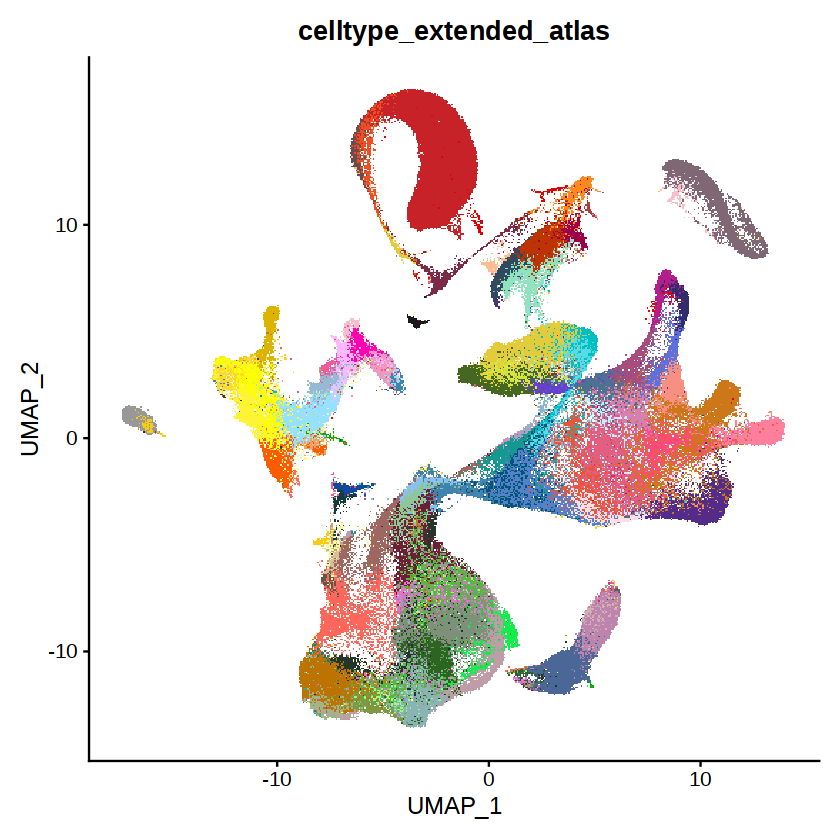

In [9]:
DimPlot(atlas.integrated, reduction = "umap", group.by='celltype_extended_atlas') + 
    scale_color_manual(values = opts$celltype.colors) + 
    NoLegend()

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



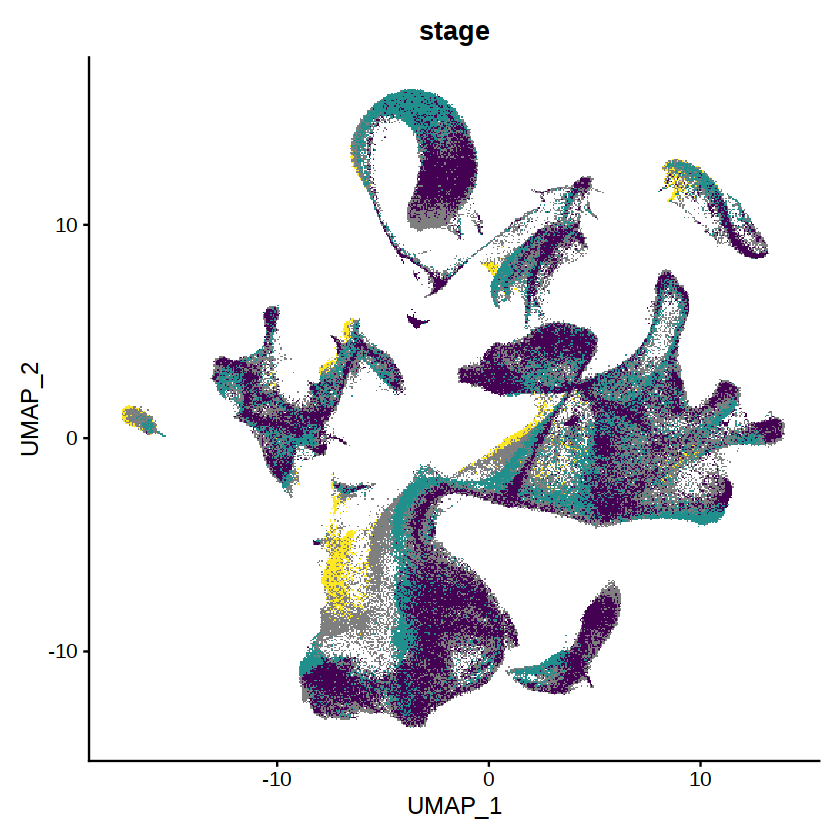

In [10]:
DimPlot(atlas.integrated, reduction = "umap", group.by='stage') + 
    scale_color_manual(values = opts$stage.colors) + 
    NoLegend()

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



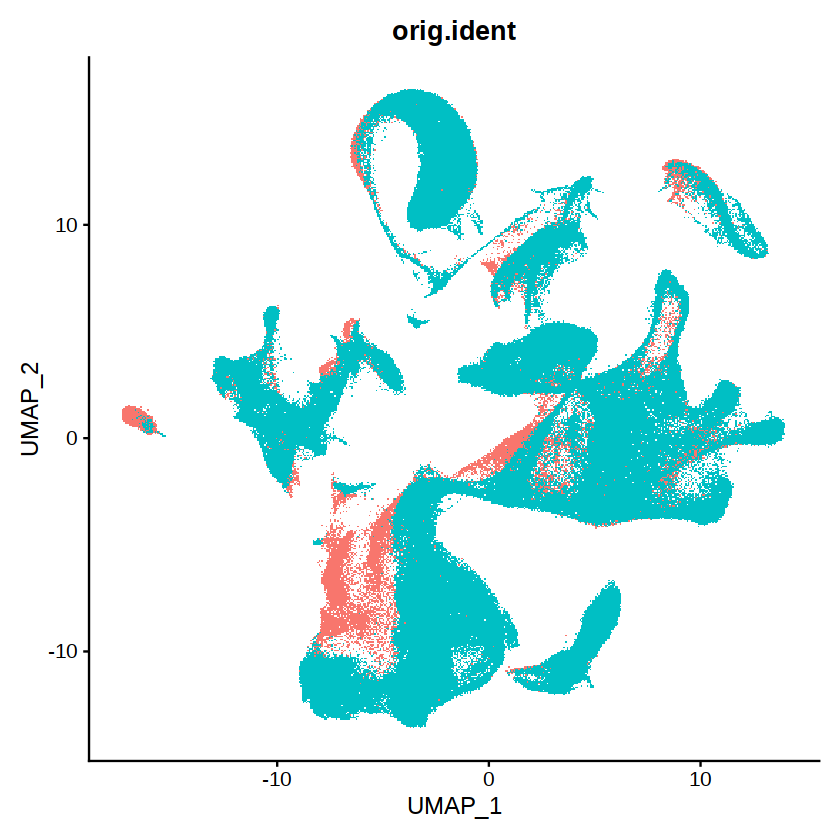

In [8]:
DimPlot(atlas.integrated, reduction = "umap", group.by='orig.ident') + NoLegend()